                     QUESTION 2: DETECTING OUTLIERS PROGRAMATICALLY AND VISUALLY

                                    LIBRARIES: PANDAS, SEABORN, MATPLOTLIB
                                    
                                    DATASETS: RAW.CSV


# Approach :

- Applied the IQR-based method to detect outliers in the dataset
- Initially evaluated outliers across the entire dataset (2012–2015)
- Further refined the approach by detecting outliers on a year-wise basis to avoid cross-year bias 

In [2]:
#importing libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Importing the dataset that contains clean data 

df = pd.read_csv('raw.csv')
df.columns = df.columns.str.lower()  #lowering the column names 

df.head()

,year,date,price
0,2012,2012-01-01,99
1,2012,2012-01-02,95
2,2012,2012-01-03,96
3,2012,2012-01-04,95
4,2012,2012-01-05,93


                                 1. IQR - BASED APPROACH ACROSS THE ENTIRE DATASET

In [4]:
# Calculate quartiles
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

# IQR
IQR = Q3 - Q1

# Bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# outliers
outliers_fullyear = df[
    (df['price'] < lower_bound) | 
    (df['price'] > upper_bound)
]
print("Number of outliers detected : ", len(outliers_fullyear))
print("-----------------------------")
print(outliers_fullyear)


Number of outliers detected :  46
-----------------------------
      year        date  price
807   2014  2014-03-19    163
809   2014  2014-03-21    165
810   2014  2014-03-22    162
814   2014  2014-03-26    166
815   2014  2014-03-27    162
816   2014  2014-03-28    166
1138  2015  2015-02-13    163
1139  2015  2015-02-14    165
1142  2015  2015-02-17    164
1148  2015  2015-02-23    163
1151  2015  2015-02-26    165
1152  2015  2015-02-27    165
1153  2015  2015-02-28    169
1154  2015  2015-03-01    162
1155  2015  2015-03-02    167
1156  2015  2015-03-03    171
1157  2015  2015-03-04    170
1158  2015  2015-03-05    168
1159  2015  2015-03-06    190
1160  2015  2015-03-07    184
1161  2015  2015-03-08    169
1162  2015  2015-03-09    176
1163  2015  2015-03-10    186
1164  2015  2015-03-11    182
1165  2015  2015-03-12    193
1166  2015  2015-03-13    281
1167  2015  2015-03-14    188
1168  2015  2015-03-15    171
1169  2015  2015-03-16    172
1170  2015  2015-03-17    176
1171  

# Results:
- There are 46 outliers in the data
- The outliers in the data come from 2014 and 2015

2014 : Outliers spike from late March dated 19th to 28th 

2015 : A massive chunk of outliers come from Feb, March and April 





# Conclusion
- The dataset did not capture the anamolies from the year 2012 and 2013
- The majority of detected outliers can be attributed to seasonal pricing behavior, while only a small subset (particularly in March 2015) represent true deviations from expected patterns.

- This highlights that outlier detection without accounting for seasonality can lead to misleading results, and emphasizes the importance of contextual and trend-aware analysis.

                            Visual plot for outlier detection on the whole dataset

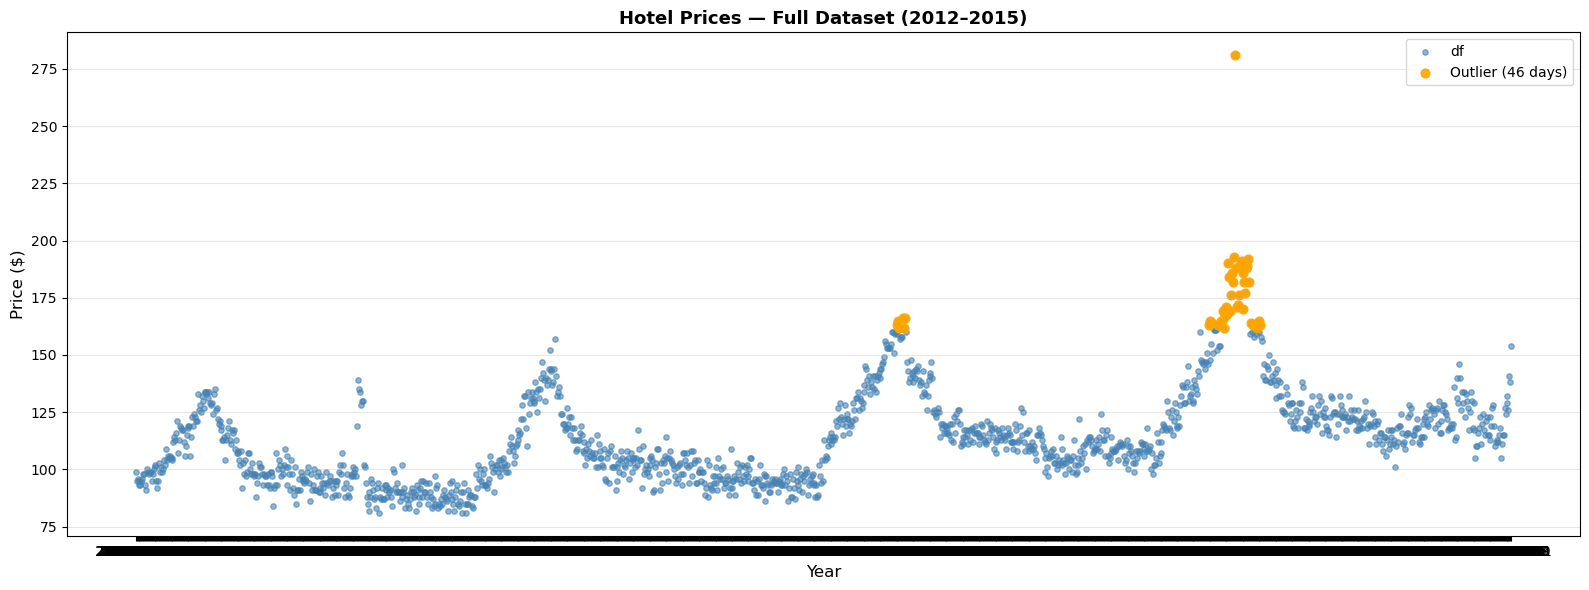

In [5]:
fig, ax = plt.subplots(figsize=(16, 6))

# All df points in blue
ax.scatter(df['date'], df['price'],
           color='steelblue', s=15, alpha=0.6, label='df')

# Outliers
ax.scatter(outliers_fullyear['date'], outliers_fullyear['price'],
           color='orange', s=40, alpha=0.9, label=f'Outlier ({len(outliers_fullyear)} days)')

ax.set_title('Hotel Prices — Full Dataset (2012–2015)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Price ($)', fontsize=12)
ax.set_xlabel('Year', fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

                                    YEAR-ON-YEAR IQR BASED APPROACH

Hotel prices have strong seasonal swings (eg During March and December) which looks like an outlier under a light threshold

Using 2×IQR raises the bar so that only prices which deviate significantly from
that year's own distribution are flagged, reducing seasonal false positives

The bounds are also computed per year (not globally) so each year's price level
is judged against itself — 2015's higher baseline doesn't penalise 2012

In [6]:
outliers_list = []
bounds = {}

for year in sorted(df['year'].unique()):
    subset = df[df['year'] == year]

    #quartiles and iqr
    Q1 = subset['price'].quantile(0.25)
    Q3 = subset['price'].quantile(0.75)
    IQR = Q3 - Q1


    # increasing the bounds to capture the outliers and not just rising trends
    lower = Q1 - 2 * IQR
    upper = Q3 + 2 * IQR
    
    bounds[year] = (lower, upper)   
    
    outliers_year = subset[
        (subset['price'] < lower) | 
        (subset['price'] > upper)
    ]
    
    outliers_list.append(outliers_year)

outliers = pd.concat(outliers_list)


In [7]:
outlierdf = pd.DataFrame(outliers)
outlierdf['Month'] = pd.to_datetime(outlierdf['date']).dt.month_name()
outlierdf.sort_values(by = ["year", "price"])

,year,date,price,Month
66,2012,2012-03-07,133,March
75,2012,2012-03-16,133,March
83,2012,2012-03-24,133,March
73,2012,2012-03-14,134,March
74,2012,2012-03-15,134,March
76,2012,2012-03-17,134,March
78,2012,2012-03-19,134,March
238,2012,2012-08-27,134,August
84,2012,2012-03-25,135,March
237,2012,2012-08-26,135,August


# Results: 
- There are 53 outliers in the data, incorporating outliers from each year
- After adjusting the threshold to account for seasonal variation, the number of false positives reduced significantly



# Conclusions:

- A consistent pattern emerges where most detected outliers occur in the month of March across all years (2012–2015). Additionally, isolated spikes are observed in August 2012.

- However, the year-over-year visualization shows that March corresponds to the peak pricing period, indicating strong seasonal demand rather than true anomalies.

- This suggests that many of the detected “outliers” are in fact a result of expected seasonal price increases, rather than irregular or erroneous data points.



                                        PLOTTING THESE OUTLIERS AS SCATTER PLOT

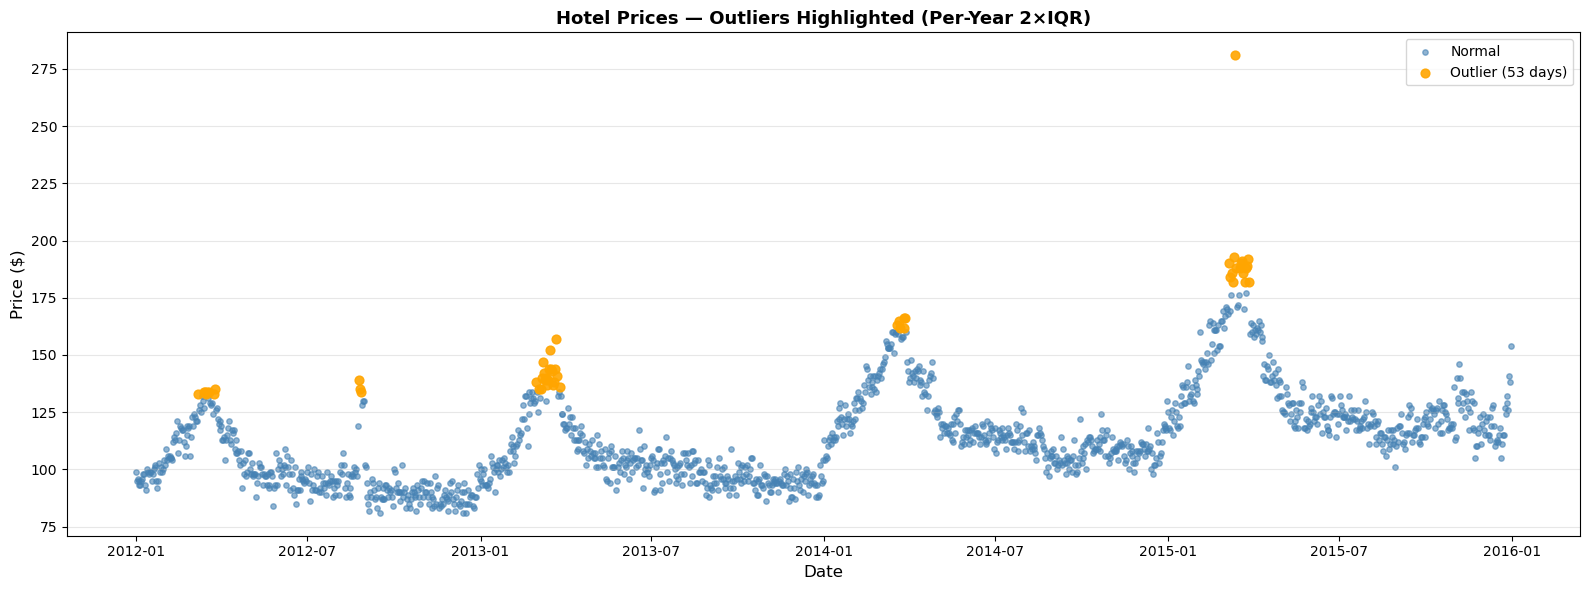

In [9]:
normal_list = []
for year in sorted(df['year'].unique()):
    subset = df[df['year'] == year]
    lower, upper = bounds[year]
    normal_year = subset[(subset['price'] >= lower) & (subset['price'] <= upper)]
    normal_list.append(normal_year)
normal = pd.concat(normal_list)


# Ensure datetime
outlierdf['date'] = pd.to_datetime(outlierdf['date'])
normal['date'] = pd.to_datetime(normal['date'])

# Sort properly
outlierdf = outlierdf.sort_values(by='date')
normal = normal.sort_values(by='date')

# Plot
fig, ax = plt.subplots(figsize=(16, 6))

ax.scatter(normal['date'], normal['price'],
           color='steelblue', s=15, alpha=0.6, label='Normal')

ax.scatter(outlierdf['date'], outlierdf['price'],
           color='orange', s=40, alpha=0.9,
           label=f'Outlier ({len(outlierdf)} days)')

ax.set_title('Hotel Prices — Outliers Highlighted (Per-Year 2×IQR)',
             fontsize=13, fontweight='bold')

ax.set_ylabel('Price ($)', fontsize=12)
ax.set_xlabel('Date', fontsize=12)

ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

                                  Conclusion — Global IQR vs Per-Year IQR


# Two outlier detection approaches were tested:

Global IQR (1.5×) — computes a single threshold across all years, flagging 46 days. This approach is too aggressive for this dataset because it treats 2015's naturally higher price level as anomalous compared to 2012, conflating year-over-year price growth with outliers

Per-Year IQR (2×) — computes thresholds independently for each year, flagging 53 days. Each year is judged against its own distribution, so a high price in 2015 is only flagged if it's unusual for 2015, and similarly for all the years